In [1]:
from datasets import load_dataset

dataset = load_dataset("yelp_polarity")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 560000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 38000
    })
})


In [2]:
import pandas as pd
# Convert to DataFrame for easier exploration
df = pd.DataFrame(dataset['train'])

print(df.shape)
print(df['label'].value_counts())
df.head(5)

(560000, 2)
label
0    280000
1    280000
Name: count, dtype: int64


,text,label
0,"Unfortunately, the frustration of being Dr. Go...",0
1,Been going to Dr. Goldberg for over 10 years. ...,1
2,I don't know what Dr. Goldberg was like before...,0
3,I'm writing this review to give you a heads up...,0
4,All the food is great here. But the best thing...,1


In [3]:
# View class distribution
print(df['label'].value_counts())

# See examples of negative and positive reviews
print("NEGATIVA:")
print(df[df['label']==0]['text'].iloc[0])
print("\nPOSITIVA:")
print(df[df['label']==1]['text'].iloc[0])

label
0    280000
1    280000
Name: count, dtype: int64
NEGATIVA:
Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff.  It seems that his staff simply never answers the phone.  It usually takes 2 hours of repeated calling to get an answer.  Who has time for that or wants to deal with it?  I have run into this problem with many other doctors and I just don't get it.  You have office workers, you have patients with medical needs, why isn't anyone answering the phone?  It's incomprehensible and not work the aggravation.  It's with regret that I feel that I have to give Dr. Goldberg 2 stars.

POSITIVA:
Been going to Dr. Goldberg for over 10 years. I think I was one of his 1st patients when he started at MHMG. He's been great over the years and is really all about the big picture. It is because of him, not my now former gyn Dr. Markoff, that I found out I have fibroids. He expl

In [4]:
df_small = df.sample(n=5000, random_state=42)

# Check class balance
print(df_small['label'].value_counts())

label
0    2533
1    2467
Name: count, dtype: int64


In [5]:
import re

def clean_text(text):
    text = text.lower()                        
    text = re.sub(r'<br />', ' ', text)        
    text = re.sub(r'[^a-zA-Z\s]', '', text)   
    text = text.strip()                        
    return text

df_small['text_clean'] = df_small['text'].apply(clean_text)

# Verificar
print(df_small['text_clean'].iloc[0])

this place is one of my favorite comic shops i actually live closer to a different one but i drive to chandler just to go to this one i like their selection and when they have the dollar sale you can get some ridiculous deals the staff is ridiculously friendly and i usually always walk out with whatever i wanted they also have some cool events from time to time and ive found their prices to be reasonable and comparable to other comic shops


In [6]:
from transformers import pipeline

# Load sentiment model
classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512
)

# Test with a review
result = classifier(df_small['text_clean'].iloc[0])
print(result)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'NEGATIVE', 'score': 0.728206217288971}]


In [7]:
from tqdm import tqdm

texts = df_small['text_clean'].tolist()
results = []

for text in tqdm(texts):
    result = classifier(text, truncation=True, max_length=512)
    results.append(1 if result[0]['label'] == 'POSITIVE' else 0)

df_small['predicted'] = results

100%|██████████| 5000/5000 [08:10<00:00, 10.19it/s]


In [8]:
from sklearn.metrics import classification_report, accuracy_score

accuracy = accuracy_score(df_small['label'], df_small['predicted'])
print(f"Accuracy: {accuracy:.2%}")
print("\n")
print(classification_report(df_small['label'], df_small['predicted']))

Accuracy: 88.52%


              precision    recall  f1-score   support

           0       0.84      0.95      0.89      2533
           1       0.94      0.82      0.88      2467

    accuracy                           0.89      5000
   macro avg       0.89      0.88      0.88      5000
weighted avg       0.89      0.89      0.88      5000



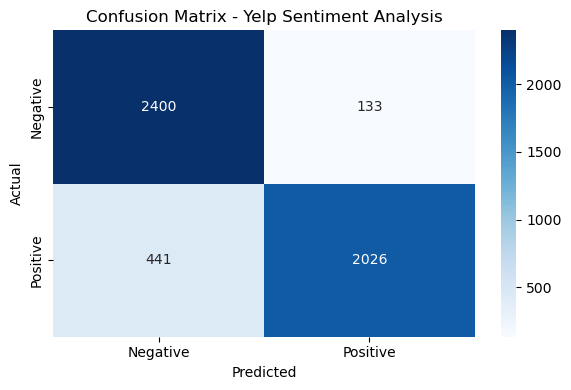

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(df_small['label'], df_small['predicted'])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Yelp Sentiment Analysis')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [10]:
from groq import Groq
import os
from dotenv import load_dotenv
load_dotenv(r"C:\Users\aleja\Desktop\Yelp-Sentimental-Analysis\.env")

client = Groq(api_key=os.getenv("groq_api_key"))


response = client.chat.completions.create(
    model="llama-3.1-8b-instant",
    messages=[{"role": "user", "content": "Say hello in one sentence"}]
)

print(response.choices[0].message.content)

Hello, how are you today?


In [11]:
def analyze_review(review_text):
    # Step 1: Predict sentiment
    result = classifier(review_text, truncation=True, max_length=512)
    sentiment = result[0]['label']
    score = result[0]['score']
    
    # Paso 2: Groq generate an advice
    prompt = f"""
    A customer left this review: "{review_text}"
    
    The sentiment analysis model classified it as {sentiment} with {score:.0%} confidence.
    
    In 2-3 sentences, explain why and give one specific business recommendation.
    """
    
    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}]
    )
    
    return {
        "review": review_text,
        "sentiment": sentiment,
        "confidence": f"{score:.0%}",
        "analysis": response.choices[0].message.content
    }


review = "The food was cold and the service was incredibly slow. Never coming back."
result = analyze_review(review)

print(f"Sentiment: {result['sentiment']} ({result['confidence']})")
print(f"\nAnalysis: {result['analysis']}")

Sentiment: NEGATIVE (100%)

Analysis: The customer's review is classified as NEGATIVE with 100% confidence because they specifically mentioned two major issues: cold food and slow service. These statements evoke feelings of disappointment and frustration, leading to a strong negative sentiment. To address this issue, the business should consider implementing a food quality control system, such as in-house temperature checks, to ensure that all meals are served at the correct temperature.


In [12]:
review = "Best restaurant I've been to in years. The staff was amazing and the food came out perfectly hot and fresh!"
result = analyze_review(review)

print(f"Sentiment: {result['sentiment']} ({result['confidence']})")
print(f"\nAnalysis: {result['analysis']}")

Sentiment: POSITIVE (100%)

Analysis: The review is classified as POSITIVE with 100% confidence because the customer uses superlatives such as "Best restaurant" and expresses genuine enthusiasm for the experience, mentioning that the food was "perfectly hot and fresh" and the staff was "amazing." This suggests that the customer had a truly exceptional dining experience. To capitalize on this positive review, I would recommend that the restaurant consider highlighting the staff's exceptional customer service and food quality on their website or social media, potentially even featuring the customer's review to attract more customers.
